# Analyse de la performance scolaire

Ce notebook présente une analyse exploratoire des données d’élèves afin d’identifier les facteurs qui influencent leur réussite scolaire.

- Nettoyage et préparation des données
- Analyse descriptive
- Comparaison des facteurs de performance
- Corrélations et interprétation


In [ ]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.4 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.4 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.4 MB 2.3 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.4 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.4 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.4 MB 2.7 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.4 MB 2.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.4 MB 2.6 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.4 MB 2.6 MB/s eta 0:00:02
   -------------------------- ----------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1. Nettoyage et préparation des données

Cette section charge le dataset, vérifie sa qualité, supprime les doublons, traite les valeurs manquantes et prépare les variables pour l’analyse.

In [2]:
# chargement des données 
try:
    df = pd.read_csv('Student_Performance.csv')
    print("Dataset chargé avec succès.")
    print(f"Dimensions initiales : {df.shape}")
except FileNotFoundError:
    print("Erreur : Le fichier 'Student_Performance.csv' est introuvable.")
    exit()

Dataset chargé avec succès.
Dimensions initiales : (25000, 16)


In [3]:
# exploration et vérification de la qualité
print("\n--- Aperçu des premières lignes ---")
print(df.head())

print("\n--- Informations sur les colonnes et types de données ---")
df.info()

print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

print("\n--- Nombre de doublons ---")
print(df.duplicated().sum())


--- Aperçu des premières lignes ---
   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes  

In [4]:
# Suppression des doublons 
df.drop_duplicates(inplace=True)
print(f"\nDimensions après suppression des doublons : {df.shape}")

# La colonne 'student_id' est un identifiant unique, elle n'est pas utile pour la prédiction.
# On la supprime.
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)
    print("Colonne 'student_id' supprimée.")


Dimensions après suppression des doublons : (15000, 16)
Colonne 'student_id' supprimée.


In [5]:
# valeurs manquantes
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nVérification des valeurs manquantes après imputation :")
print(df.isnull().sum().sum())


Vérification des valeurs manquantes après imputation :
0


In [6]:
# valeurs abérrentes
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # On applique le capping
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

outlier_cols = ['study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score']
for col in outlier_cols:
    if col in df.columns:
        df = cap_outliers(df, col)

print("\nTraitement des valeurs aberrantes terminé.")


Traitement des valeurs aberrantes terminé.


In [7]:
# Colonnes catégorielles à encoder en One-Hot
cat_cols_to_encode = ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']

# Mapping pour la colonne 'final_grade' (ordre alphabétique)
grade_mapping = {'a': 6, 'b': 5, 'c': 4, 'd': 3, 'e': 2, 'f': 1}
df['final_grade_encoded'] = df['final_grade'].map(grade_mapping)

# On supprime la colonne originale 'final_grade' et on garde l'encodée
df = df.drop('final_grade', axis=1)

# On applique le One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=False)

print("\nEncodage des variables catégorielles terminé.")
print(f"Nouvelles dimensions après encodage : {df.shape}")


Encodage des variables catégorielles terminé.
Nouvelles dimensions après encodage : (15000, 33)


In [8]:
df.to_csv('Student_Performance_Cleaned.csv', index=False)
print("\nDataset nettoyé et préparé sauvegardé sous le nom 'Student_Performance_Cleaned.csv'.")

# Affichage final
print("\n--- Aperçu du dataset final ---")
print(df.head())
print(f"\nDimensions finales : {df.shape}")


Dataset nettoyé et préparé sauvegardé sous le nom 'Student_Performance_Cleaned.csv'.

--- Aperçu du dataset final ---
   age  study_hours  attendance_percentage  math_score  science_score  \
0   14          3.1                   84.3        42.7           55.4   
1   18          3.7                   87.8        57.6           68.8   
2   17          7.9                   65.5        84.8           95.0   
3   16          1.1                   58.1        44.4           27.5   
4   16          1.3                   61.0         8.9           32.7   

   english_score  overall_score  final_grade_encoded  gender_female  \
0           57.0           53.1                    2          False   
1           64.8           61.3                    3           True   
2           79.2           89.6                    5           True   
3           54.7           41.6                    2          False   
4           30.0           25.4                    1           True   

   gender_male 

## 2. Analyse exploratoire de la performance scolaire

On étudie ici la distribution des notes, les facteurs associés à la réussite et les corrélations entre les variables importantes.

In [9]:
df['final_grade_encoded'] = df['final_grade_encoded'].astype(object) # transformation de la colonne 'final_grade_encoded' en type object pour l'analyse descriptive
df.head(5)

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,final_grade_encoded,gender_female,gender_male,...,travel_time_<15 min,travel_time_>60 min,extra_activities_no,extra_activities_yes,study_method_coaching,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,14,3.1,84.3,42.7,55.4,57.0,53.1,2,False,True,...,True,False,False,True,False,False,False,True,False,False
1,18,3.7,87.8,57.6,68.8,64.8,61.3,3,True,False,...,False,True,True,False,False,False,False,False,False,True
2,17,7.9,65.5,84.8,95.0,79.2,89.6,5,True,False,...,True,False,True,False,False,False,False,True,False,False
3,16,1.1,58.1,44.4,27.5,54.7,41.6,2,False,False,...,False,False,True,False,False,False,False,True,False,False
4,16,1.3,61.0,8.9,32.7,30.0,25.4,1,True,False,...,False,False,False,True,False,True,False,False,False,False


In [10]:
# Analyse descritives
Var_quanti = df.describe()
Var_quanti

,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,16.476400,4.25936,74.991760,63.774670,63.751253,63.709327,64.015500
std,1.704475,2.17244,14.401139,20.919603,21.027595,20.859898,18.977811
min,14.000000,0.50000,50.000000,0.350000,0.100000,0.750000,14.500000
25%,15.000000,2.40000,62.600000,48.200000,48.100000,48.300000,49.000000
50%,16.000000,4.30000,75.000000,64.100000,64.000000,64.200000,64.300000
75%,18.000000,6.10000,87.400000,80.100000,80.100000,80.000000,79.100000
max,19.000000,8.00000,100.000000,100.000000,100.000000,100.000000,100.000000


In [11]:
Resume = print(f""" Analyses descriptives des variables quantitatives:
L'age moyen des élèves était de {round(df['age'].mean(), 2)} ans avec un écart type de {round(df['age'].std(), 2)} ans. 
Le moins agé avait {df['age'].min()} ans et le plus agé avait {df['age'].max()} ans.
Un élève étudiait en moyenne {round(df['study_hours'].mean(), 2)} heures par jour avec un écart type de {round(df['study_hours'].std(), 2)} heures.
50% des élèves avaient une assiduité supérieure à {df['attendance_percentage'].median()}%.
La moyenne générale en science était de {round(df['science_score'].mean(), 2)}, elle ne différait pas beaucoup de la moyenne générale médiane {round(df['science_score'].median(), 2)}.""")

 Analyses descriptives des variables quantitatives:
L'age moyen des élèves était de 16.48 ans avec un écart type de 1.7 ans. 
Le moins agé avait 14 ans et le plus agé avait 19 ans.
Un élève étudiait en moyenne 4.26 heures par jour avec un écart type de 2.17 heures.
50% des élèves avaient une assiduité supérieure à 75.0%.
La moyenne générale en science était de 63.75, elle ne différait pas beaucoup de la moyenne générale médiane 64.0.


In [12]:
var_quali = df.describe(include=['object', 'boolean'])
var_quali

,final_grade_encoded,gender_female,gender_male,gender_other,school_type_private,school_type_public,parent_education_diploma,parent_education_graduate,parent_education_high school,parent_education_no formal,...,travel_time_<15 min,travel_time_>60 min,extra_activities_no,extra_activities_yes,study_method_coaching,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,...,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,6,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,3,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
freq,3770,10021,10021,9958,7587,7587,12419,12519,12468,12555,...,11352,11284,7506,7506,12578,12553,12398,12485,12532,12454


In [13]:
Resume = print(f""" Analyses descriptives des variables qualitatives:
{round(sum(df['gender_male']==False)/len(df)*100,2)}% des élèves étaient des filles.
Seul {round(sum(df['final_grade_encoded']==6)/len(df)*100, 2)}% élèves ont obtenu la note A. La majorité d'entre {round(sum(df['final_grade_encoded']==4)/len(df)*100, 2)}%, eux ont obtenu la note C .
{round(sum(df['school_type_public']==True)/len(df)*100, 2)}% des élèves fréquentaient une école publique, et plus de {round(sum(df['internet_access_yes']==True)/len(df)*100, 2)}% des élèves avaient accès à internet à la maison.
{round(sum(df['extra_activities_yes']==True)/len(df)*100, 2)}% des élèves participaient à des activités extrascolaires et {round(sum(df['study_method_group study']==True)/len(df)*100, 2)}% des élèves étudiaient en groupe.""")

 Analyses descriptives des variables qualitatives:
66.81% des élèves étaient des filles.
Seul 4.81% élèves ont obtenu la note A. La majorité d'entre 24.65%, eux ont obtenu la note C .
49.42% des élèves fréquentaient une école publique, et plus de 85.03% des élèves avaient accès à internet à la maison.
49.96% des élèves participaient à des activités extrascolaires et 16.31% des élèves étudiaient en groupe.


In [14]:
# Répartitio du niveau d'éducation des parents
tab = pd.DataFrame({"Parent gradué": [round(sum(df['parent_education_graduate']==True)/len(df)*100, 2)], "Parent ayant fait le lycée": [round(sum(df['parent_education_high school']==False)/len(df)*100, 2)],
                    "Parent non scolaires": [round(sum(df['parent_education_no formal']==True)/len(df)*100, 2)],
                    "Parent ayant un phd" : [round(sum(df['parent_education_phd']==True)/len(df)*100, 2)],
                    "Parent post gradué": [round(sum(df['parent_education_post graduate']==True)/len(df)*100, 2)],
                    "Parent diplomés": [round(sum(df['parent_education_diploma']==True)/len(df)*100, 2)]})
tab

,Parent gradué,Parent ayant fait le lycée,Parent non scolaires,Parent ayant un phd,Parent post gradué,Parent diplomés
0,16.54,83.12,16.3,16.17,16.9,17.21


### 2.1. Impact de l’âge sur la performance

Nous testons si l’âge influence l’assiduité et la note moyenne des élèves.

In [ ]:
grouped_df = df.groupby('age').agg({
    'attendance_percentage': 'mean',
    'overall_score': 'mean'
}).reset_index()

grouped_df

,age,attendance_percentage,overall_score
0,14,75.072176,64.230697
1,15,75.124832,63.929577
2,16,74.344832,63.582933
3,17,75.032902,63.495456
4,18,75.238540,64.676794
5,19,75.142015,64.205897


L'assiduité et la note générale reste constante quelque soit l'âge. Cette observation observation suggere que l'âge n'a pas un fort impact sur la performance scolaire

### 2.2. Genre et type d’école

On compare la moyenne générale selon le sexe et le type d’établissement.

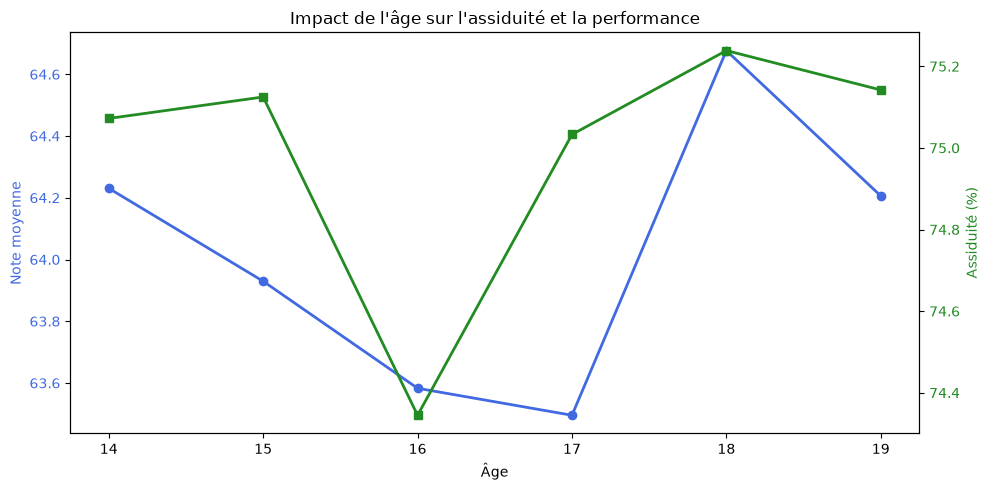

In [16]:
# Impact de l'âge sur la performance
grouped_age = df.groupby('age').agg(
    assiduite=('attendance_percentage', 'mean'),
    note=('overall_score', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(grouped_age['age'], grouped_age['note'], marker='o', color='royalblue', linewidth=2, label='Note moyenne')
ax1.set_xlabel('Âge')
ax1.set_ylabel('Note moyenne', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

ax2 = ax1.twinx()
ax2.plot(grouped_age['age'], grouped_age['assiduite'], marker='s', color='forestgreen', linewidth=2, label='Assiduité moyenne')
ax2.set_ylabel('Assiduité (%)', color='forestgreen')
ax2.tick_params(axis='y', labelcolor='forestgreen')

plt.title("Impact de l'âge sur l'assiduité et la performance")
fig.tight_layout()
plt.show()

In [ ]:
grouped_gender=df.groupby(["gender_male","school_type_public"])["overall_score"].mean().sort_values(ascending=False)
grouped_gender

gender_male  school_type_public
False        False                 64.067861
             True                  64.027190
True         False                 63.972619
             True                  63.928016
Name: overall_score, dtype: float64

### 2.3. Niveau d’éducation des parents

Cette analyse mesure si le niveau d’instruction des parents est lié aux performances scolaires des élèves.

La moyenne générale des filles est légèrement plus élevé chez les filles que chez les garçons indépendamment du types d'écoles. Cependant la différence entre les types d'écoles n'est pas très grande. Cela suggère que le genre a un effet mais son action reste modérée.

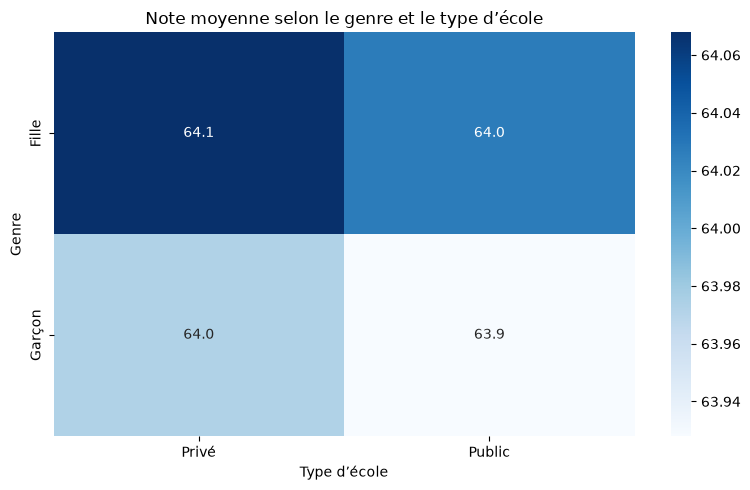

In [17]:
# Genre et type d'école
gender_school = df.groupby(['gender_male', 'school_type_public']).agg(
    note_moyenne=('overall_score', 'mean')
).reset_index()

gender_school['genre'] = np.where(gender_school['gender_male'] == 1, 'Garçon', 'Fille')
gender_school['type_ecole'] = np.where(gender_school['school_type_public'] == 1, 'Public', 'Privé')

pivot = gender_school.pivot_table(index='genre', columns='type_ecole', values='note_moyenne', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.1f')
plt.title('Note moyenne selon le genre et le type d’école')
plt.xlabel('Type d’école')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### 2.4. Accès internet et activités extrascolaires

On examine si la disponibilité d’Internet et la pratique d’activités parascolaires influencent la moyenne générale.

In [ ]:
grouped_parent = df.groupby(['parent_education_graduate', 'parent_education_post graduate', 'parent_education_phd', 'parent_education_high school',
                         'parent_education_no formal', 'parent_education_diploma']).agg({ 
    'overall_score': 'mean'
}).reset_index()

grouped_parent

,parent_education_graduate,parent_education_post graduate,parent_education_phd,parent_education_high school,parent_education_no formal,parent_education_diploma,overall_score
0,False,False,False,False,False,True,64.773382
1,False,False,False,False,True,False,63.653006
2,False,False,False,True,False,False,63.445972
3,False,False,True,False,False,False,63.938417
4,False,True,False,False,False,False,64.303748
5,True,False,False,False,False,False,63.946393


Les enfants ayant des parents diplômés et post graduiés ont une meilleure note générale que les autres.

### 2.5. Méthodes d’étude

Nous comparons la note moyenne selon la méthode de travail utilisée par les élèves.

C:\Users\congo\AppData\Local\Temp\ipykernel_12732\2360378460.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_parent, x='Niveau', y='Note moyenne', palette='viridis')


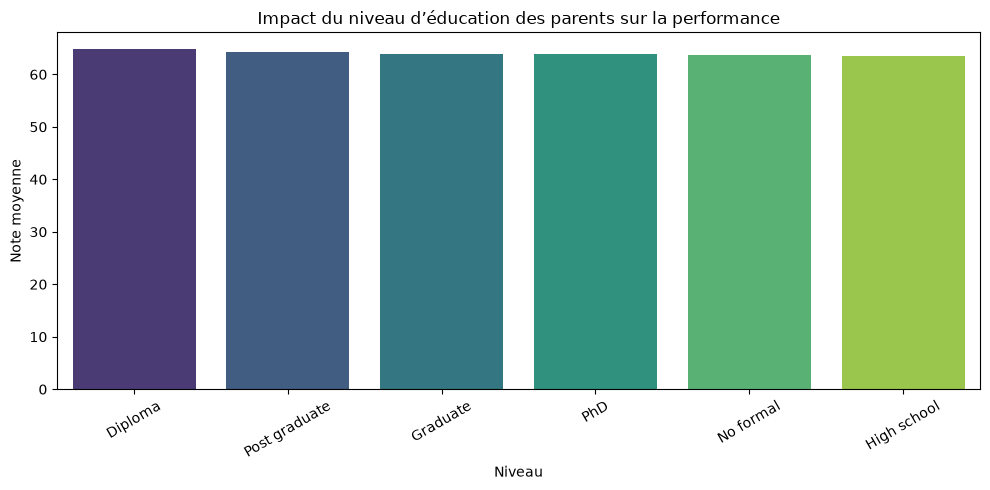

In [19]:
# Niveau d'éducation des parents
parent_cols = [
    'parent_education_graduate',
    'parent_education_post graduate',
    'parent_education_phd',
    'parent_education_high school',
    'parent_education_no formal',
    'parent_education_diploma'
]
parent_labels = ['Graduate', 'Post graduate', 'PhD', 'High school', 'No formal', 'Diploma']

scores = []
for col, label in zip(parent_cols, parent_labels):
    if col in df.columns:
        note = df.loc[df[col].astype(bool), 'overall_score'].mean()
        scores.append((label, note))

df_parent = pd.DataFrame(scores, columns=['Niveau', 'Note moyenne']).sort_values('Note moyenne', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_parent, x='Niveau', y='Note moyenne', palette='viridis')
plt.title('Impact du niveau d’éducation des parents sur la performance')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
pivot_tab = df.pivot_table(
    values="overall_score",
    index="internet_access_yes",
    columns="extra_activities_yes",
    aggfunc="mean"
)

pivot_tab

extra_activities_yes,False,True
internet_access_yes,,
False,63.295888,64.436627
True,64.090005,63.997340


### 2.6. Performance par matière

Cette section compare les moyennes des scores en mathématiques, sciences et anglais.

Ne pas avoir accès à internet mais faire des activités extra scolaire et inversement avoir accès à internet et ne pas faire d'activité extra scolaire améliore la moyenne générale. Tandis qu'aucun accès n'a internet ni à des activités extra scolaire n'améliore la note générale.

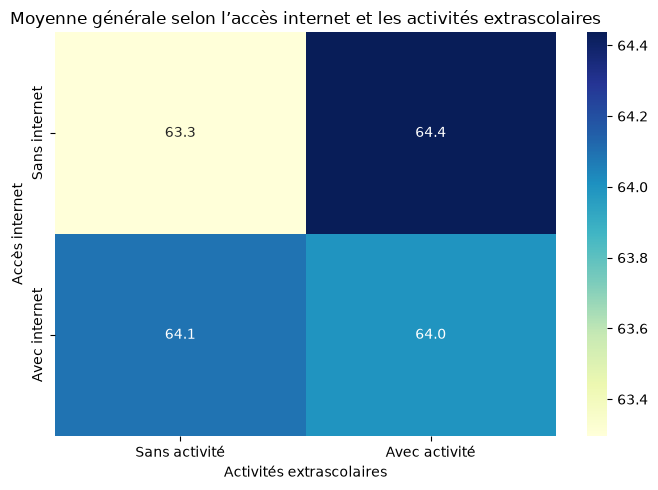

In [21]:
# Accès internet et activités extrascolaires
pivot_internet = df.pivot_table(
    values='overall_score',
    index='internet_access_yes',
    columns='extra_activities_yes',
    aggfunc='mean'
)

pivot_internet.index = ['Sans internet', 'Avec internet']
pivot_internet.columns = ['Sans activité', 'Avec activité']

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_internet, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Moyenne générale selon l’accès internet et les activités extrascolaires')
plt.xlabel('Activités extrascolaires')
plt.ylabel('Accès internet')
plt.tight_layout()
plt.show()

### 2.7. Répartition des notes finales

On regarde la distribution des notes finales pour voir comment les résultats se répartissent entre les élèves.

In [22]:
grouped_study_method = df.groupby(['study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos',
                         'study_method_textbook', 'study_method_coaching']).agg({ 
    'overall_score': 'mean'
}).reset_index()

grouped_study_method

,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook,study_method_coaching,overall_score
0,False,False,False,False,False,True,64.476259
1,False,False,False,False,True,False,64.190024
2,False,False,False,True,False,False,64.683063
3,False,False,True,False,False,False,63.858012
4,False,True,False,False,False,False,63.653574
5,True,False,False,False,False,False,63.251287


## 3. Corrélations entre variables clés

Cette partie mesure le lien entre les heures d’étude, l’assiduité et la performance globale.

Utiliser des textbook, avoir un répétiteur et regarder des vidéo comme méthode de travail est celle qui permet d'avoir la moyenne générale la plus élevée.

C:\Users\congo\AppData\Local\Temp\ipykernel_12732\3104516265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_study, x='Méthode', y='Note moyenne', palette='rocket')


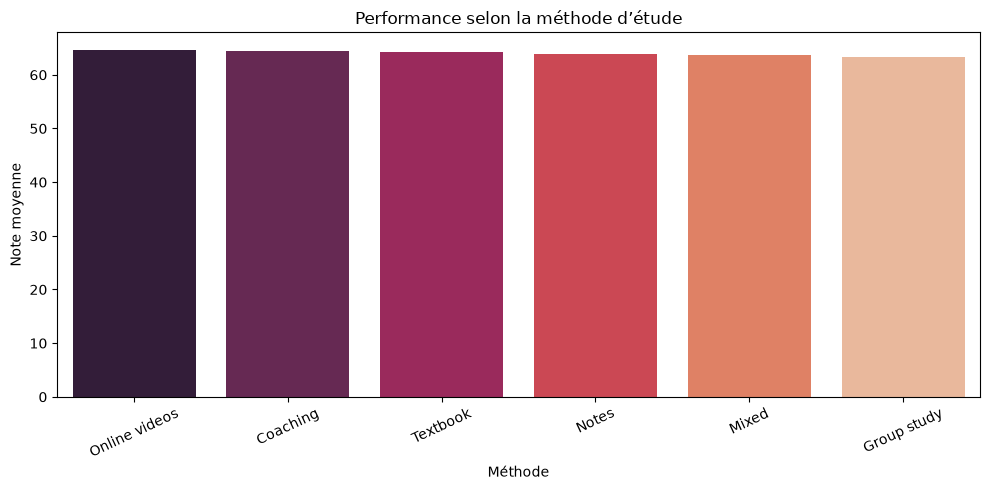

In [23]:
# Méthode d’étude
study_cols = [
    'study_method_group study',
    'study_method_mixed',
    'study_method_notes',
    'study_method_online videos',
    'study_method_textbook',
    'study_method_coaching'
]
study_labels = ['Group study', 'Mixed', 'Notes', 'Online videos', 'Textbook', 'Coaching']

scores = []
for col, label in zip(study_cols, study_labels):
    if col in df.columns:
        note = df.loc[df[col].astype(bool), 'overall_score'].mean()
        scores.append((label, note))

df_study = pd.DataFrame(scores, columns=['Méthode', 'Note moyenne']).sort_values('Note moyenne', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_study, x='Méthode', y='Note moyenne', palette='rocket')
plt.title('Performance selon la méthode d’étude')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
moy_matiere = df[["math_score", "science_score", "english_score"]].mean().sort_values(ascending=False)
moy_matiere

math_score       63.774670
science_score    63.751253
english_score    63.709327
dtype: float64

La performance ne diffère pas entre les différentes matières scientifiques

C:\Users\congo\AppData\Local\Temp\ipykernel_12732\2058487757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matiere.index, y=matiere.values, palette='Set2')


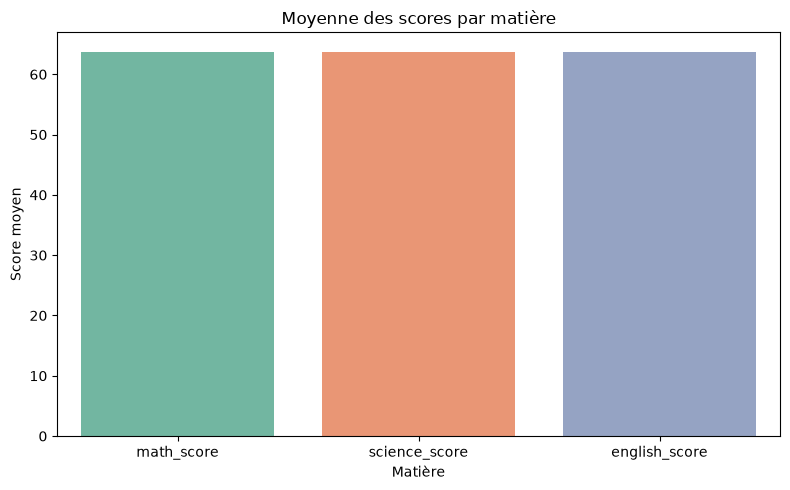

In [25]:
# Performance par matière
matiere = df[['math_score', 'science_score', 'english_score']].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=matiere.index, y=matiere.values, palette='Set2')
plt.title('Moyenne des scores par matière')
plt.ylabel('Score moyen')
plt.xlabel('Matière')
plt.tight_layout()
plt.show()

In [ ]:
repartition_note = df["final_grade_encoded"].value_counts()/len(df)*100
repartition_note.round(2).sort_index()

final_grade_encoded
1    11.97
2    22.52
3    25.13
4    24.65
5    10.92
6     4.81
Name: count, dtype: float64

C:\Users\congo\AppData\Local\Temp\ipykernel_12732\3463663582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=grade_counts.values, palette='coolwarm')


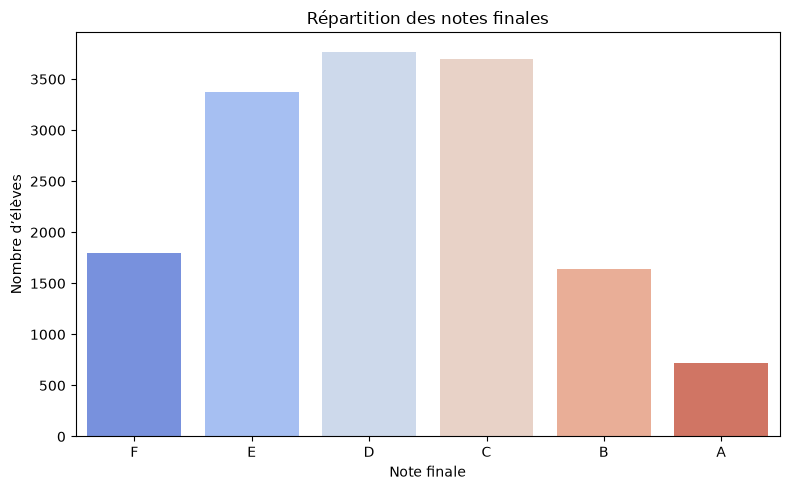

In [27]:
# Répartition des notes finales
grade_counts = df['final_grade_encoded'].value_counts().sort_index()
grade_labels = {1: 'F', 2: 'E', 3: 'D', 4: 'C', 5: 'B', 6: 'A'}
labels = [grade_labels.get(i, str(i)) for i in grade_counts.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=grade_counts.values, palette='coolwarm')
plt.title('Répartition des notes finales')
plt.xlabel('Note finale')
plt.ylabel('Nombre d’élèves')
plt.tight_layout()
plt.show()

In [ ]:
r_etude, p_etude = pearsonr(df['study_hours'], df['overall_score'])
print(f"Coefficient de corrélation entre le temps d'étude et la performance scolaire : {r_etude:.2f}, p-value : {p_etude:.4f}")


Coefficient de corrélation entre le temps d'étude et la performance scolaire : 0.91, p-value : 0.0000


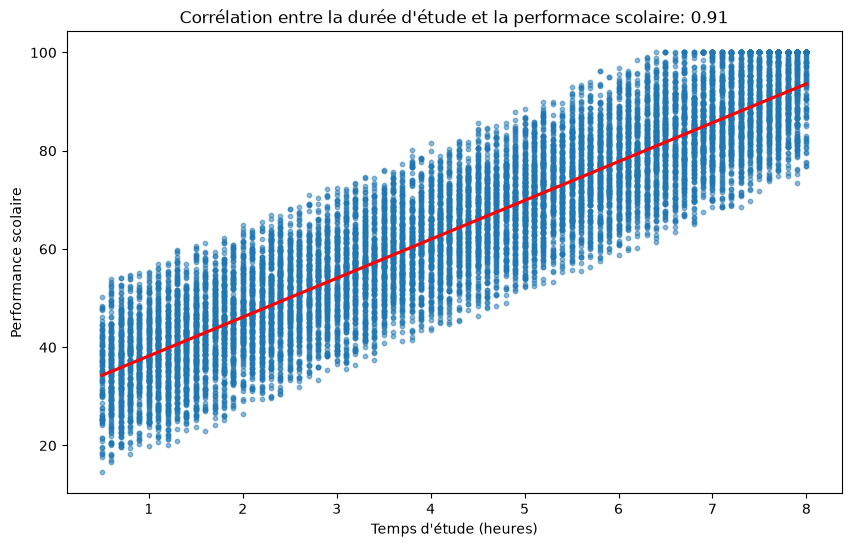

In [29]:
plt.figure(figsize=(10, 6))
sns.regplot(x='study_hours', y='overall_score', data=df, scatter_kws={'alpha':0.5, 's':10}, line_kws={'color':'red'})  
plt.xlabel('Temps d\'étude (heures)')
plt.ylabel('Performance scolaire') 
plt.title(f'Corrélation entre la durée d\'étude et la performace scolaire: {r_etude:.2f}')
plt.show()

In [ ]:
r_assid, p_assid = pearsonr(df['attendance_percentage'], df['overall_score'])
print(f"Coefficient de corrélation : {r_assid:.2f}, p-value : {p_assid:.4f}")

Coefficient de corrélation : 0.29, p-value : 0.0000


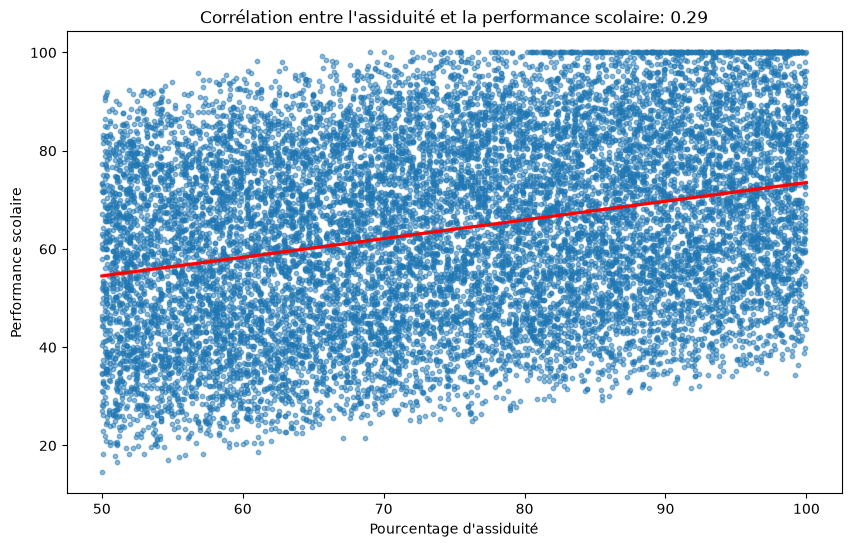

In [32]:
plt.figure(figsize=(10, 6))
sns.regplot(x='attendance_percentage', y='overall_score', data=df, scatter_kws={'alpha':0.5, 's':10}, line_kws={'color':'red'})
plt.xlabel('Pourcentage d\'assiduité')
plt.ylabel('Performance scolaire')
plt.title(f'Corrélation entre l\'assiduité et la performance scolaire: {r_assid:.2f}')
plt.show()